FileNotFoundError: [Errno 2] No such file or directory: '../log/log.txt'

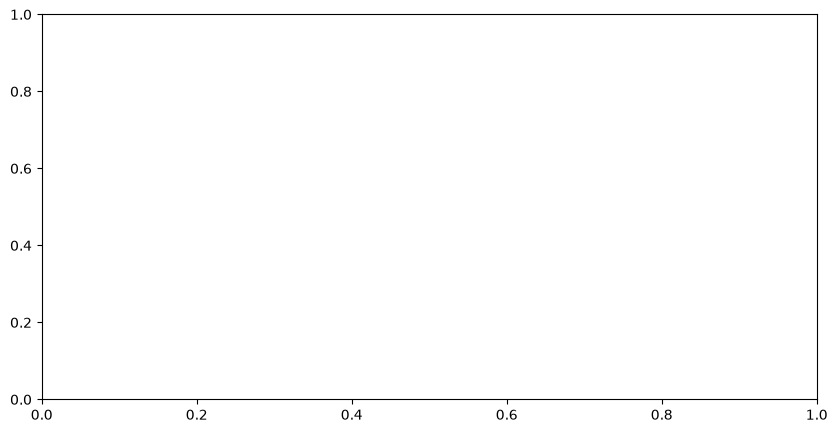

In [82]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import re

LOG_FILE = "../log/log.txt"

plt.ion()
fig, ax = plt.subplots(figsize=(10, 5))

dt_values = []

with open(LOG_FILE, "r") as f:
    for line in f:
        match = re.search(r"dt=([\d.eE+-]+)", line)
        if match:
            dt_values.append(float(match.group(1)))

total = np.sum(dt_values)

print(f"Steps: {len(dt_values)}")
print(f"Total time: {total:.2f} seconds")
print(f"Total time: {total / 60:.2f} minutes")
print(f"Total time: {total / 3600:.2f} hours")



steps = []
losses = []

try:
    with open(LOG_FILE, "r") as f:
        for line in f:
            parts = line.split()

            if len(parts) >= 3 and parts[1] == "train":
                try:
                    steps.append(int(parts[0]))
                    losses.append(float(parts[2]))
                except ValueError:
                    pass

    ax.clear()

    if steps:
        ax.plot(steps, losses, linewidth=1)

        # Rolling average for a smoother trend
        window = min(100, len(losses))
        if window > 1:
            smoothed = []
            for i in range(len(losses)):
                start = max(0, i - window + 1)
                smoothed.append(sum(losses[start:i+1]) / (i - start + 1))

            ax.plot(steps, smoothed, linewidth=2)

        # Rolling average for a smoother trend
        window = min(750, len(losses))
        if window > 1:
            smoothed = []
            for i in range(len(losses)):
                start = max(0, i - window + 1)
                smoothed.append(sum(losses[start:i+1]) / (i - start + 1))

            ax.plot(steps, smoothed, linewidth=2, color='red')    


        ax.set_xlabel("Training Step")
        ax.set_ylabel("Training Loss")
        ax.set_title(f"Gouda Training — Step {steps[-1]:,}")
        ax.set_ylim(bottom=2.8, top=4)
        ax.grid(True, alpha=0.3)

except FileNotFoundError:
    print(f"Waiting for {LOG_FILE}...")

lowest_loss =min(losses)

print(lowest_loss)